# **Dry Beans Classification - Data Preprocessing**

## 📋 Problem Overview

**Objective:** Predict the type of dry bean from its shape features  
**Problem Type:** Multiclass Classification (7 classes)

**Classes:** BARBUNYA, SIRA, HOROZ, DERMASON, CALI, BOMBAY, SEKER  
**Features:** 16 continuous geometric measurements (Area, Perimeter, Eccentricity, etc.)

---
> **Student Instructions:** Complete every cell that contains a `# TODO` comment.  
> Each sub-task is labelled **(a)**, **(b)**, **(c)** … in order.  
> Do **not** change any function signatures or variable names.


## **Environment**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/gdrive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## **Data Loading**

In [ ]:
# TODO (a): Load the CSV file from Google Drive into a DataFrame called df_full
#           Path: '/content/gdrive/MyDrive/machine_learning/machine_learning_project/df.csv'
# YOUR CODE HERE
path='/content/gdrive/MyDrive/machine_learning/Classification_project_2/df.csv'
df_full=pd.read_csv(path)
# TODO (b): Print a basic overview of the dataset:
#           - First 5 rows  (.head())
#           - Shape
#           - Memory usage in MB  (use .memory_usage(deep=True).sum() / 1024**2)
#           - Column info        (.info())
#           - Descriptive stats  (.describe())
# YOUR CODE HERE
print(f'----FIRST 5 ROW----\n{df_full.head()}')
print(f'----SHAPE----\n{df_full.shape}')
print(f'----MEMORY USAGE----\n{(df_full.memory_usage(deep=True).sum() / 1024**2) :.2f}MB')
print(f'----COLUMN INFO----\n')
column_info=df_full.info()
print(column_info)
print(f'----DESCRIPTIVE STATS----\n{df_full.describe()}')

----FIRST 5 ROW----
   ID   Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0   0  58238    971.303       397.202654       186.945510      2.124697   
1   1  44515    757.601       265.590470       213.967453      1.241266   
2   2  31662    653.783       239.902428       168.421505      1.424417   
3   3  38778    734.020       268.446281       184.061923      1.458456   
4   4  42530    775.403       281.212824       193.236878      1.455275   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.882317       58977     272.306674  0.604756  0.987470   0.775723   
1      0.592420       44780     238.071960  0.771745  0.994082   0.974620   
2      0.712136       32034     200.781748  0.801407  0.988387   0.930853   
3      0.727925       39208     222.201897  0.766137  0.989033   0.904439   
4      0.726511       43028     232.703412  0.729816  0.988426   0.888895   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFac

## **1. Data Quality Assessment (BEFORE SPLITTING)**

In [ ]:
def assess_data_quality(df):
    # TODO (a): Check and print the number of missing values per column.
    #           Print "✅ No missing values!" if none are found.
    print("\n1️⃣ MISSING VALUES:")
    # YOUR CODE HERE
    # Calculate the sum of missing values for each column
    missing_values = df_full.isnull().sum()
    # Print the detailed count per column
    print("--- Missing Values Per Column ---")
    print(missing_values)
    # Final check logic
    if missing_values.sum() == 0:
      print("\n✅ No missing values!")
    else:
      print(f"\n⚠️ Warning: Found {missing_values.sum()} missing values total.")
    # TODO (b): Check and print the number of duplicate rows.
    print("\n2️⃣ DUPLICATE ROWS:")
    # YOUR CODE HERE
    duplicates=df_full.duplicated().sum()
    print(f'Number of duplicate rows: {duplicates}')
    # TODO (c): Check for negative values in numeric columns.
    #           Print a warning for each column that contains negatives.
    #           Print "✅ No negative values found in numeric features!" if none.
    print("\n3️⃣ NEGATIVE VALUES:")
    # YOUR CODE HERE
    columns_to_check = df_full.drop("y", axis=1)
    negative_mask = (columns_to_check < 0)
    # Check if ANY negatives exist
    if negative_mask.any().any():
      print("⚠️ Warning: Found negative values!")
    # Loop through columns to find exactly where
      for col in columns_to_check.columns:
        if negative_mask[col].any():
            # This shows the rows (index) where the negative values occur
          bad_rows = columns_to_check.index[negative_mask[col]]
          print(f" - Column '{col}' has negatives at row(s): {list(bad_rows)}")
    else:
      print("✅ No negative values found in numeric features!")
    # TODO (d): If the column 'y' exists, print the count and percentage
    #           of each class in the target variable.
    if 'y' in df.columns:
        print("\n4️⃣ TARGET DISTRIBUTION:")
        # YOUR CODE HERE
        # TODO (d): If the column 'y' exists, print the count and percentage
        # Get raw counts
        counts = df_full['y'].value_counts()
        # Get percentages (normalize=True converts counts to ratios)
        percentages = df_full['y'].value_counts(normalize=True) * 100
        # Combine into a clean table
        dist_table = pd.concat([counts, percentages], axis=1, keys=['Count', 'Percentage (%)'])
        # Print the table formatted to 2 decimal places
        print(dist_table.round(2))

assess_data_quality(df_full)


1️⃣ MISSING VALUES:
--- Missing Values Per Column ---
ID                 0
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
y                  0
dtype: int64

✅ No missing values!

2️⃣ DUPLICATE ROWS:
Number of duplicate rows: 0

3️⃣ NEGATIVE VALUES:
✅ No negative values found in numeric features!

4️⃣ TARGET DISTRIBUTION:
          Count  Percentage (%)
y                              
DERMASON   2837           26.19
SIRA       2109           19.47
SEKER      1621           14.96
HOROZ      1488           13.73
CALI       1304           12.04
BARBUNYA   1057            9.76
BOMBAY      418            3.86


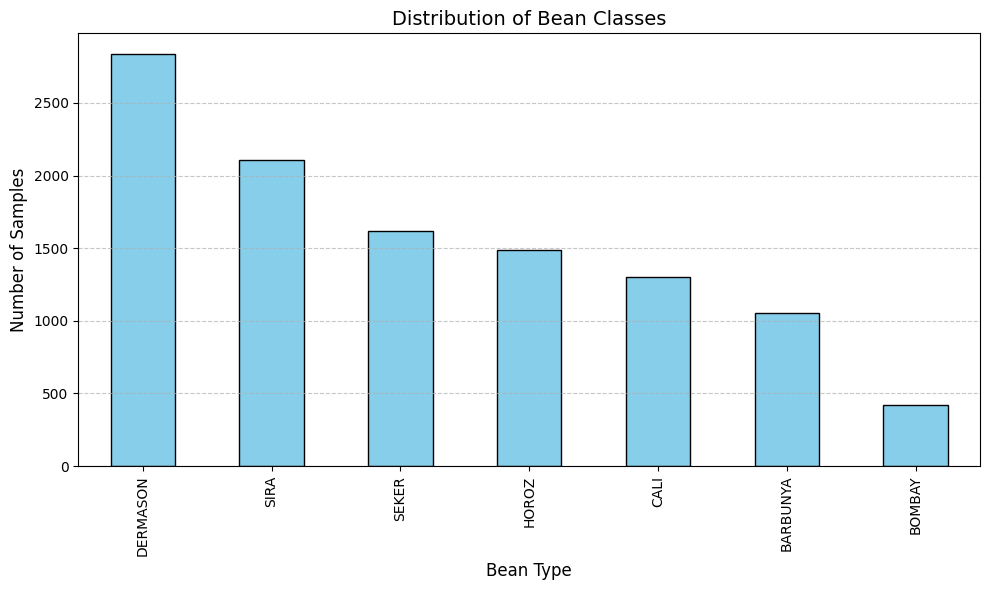

In [ ]:
# TODO (a): Create a bar chart showing the count of each bean class.
#           - x-axis: bean class names   (use df_full['y'].value_counts())
#           - y-axis: number of samples
#           - Add a title, axis labels, and a light horizontal grid.
# YOUR CODE HERE
# 1. Prepare the data
bean_counts = df_full['y'].value_counts()

# 2. Create the bar chart
plt.figure(figsize=(10, 6))
bean_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Add styling (Title, Labels, and Grid)
plt.title('Distribution of Bean Classes', fontsize=14)
plt.xlabel('Bean Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Display the chart
plt.tight_layout()
plt.show()

## **2. Visualize Outliers (BEFORE SPLITTING)**

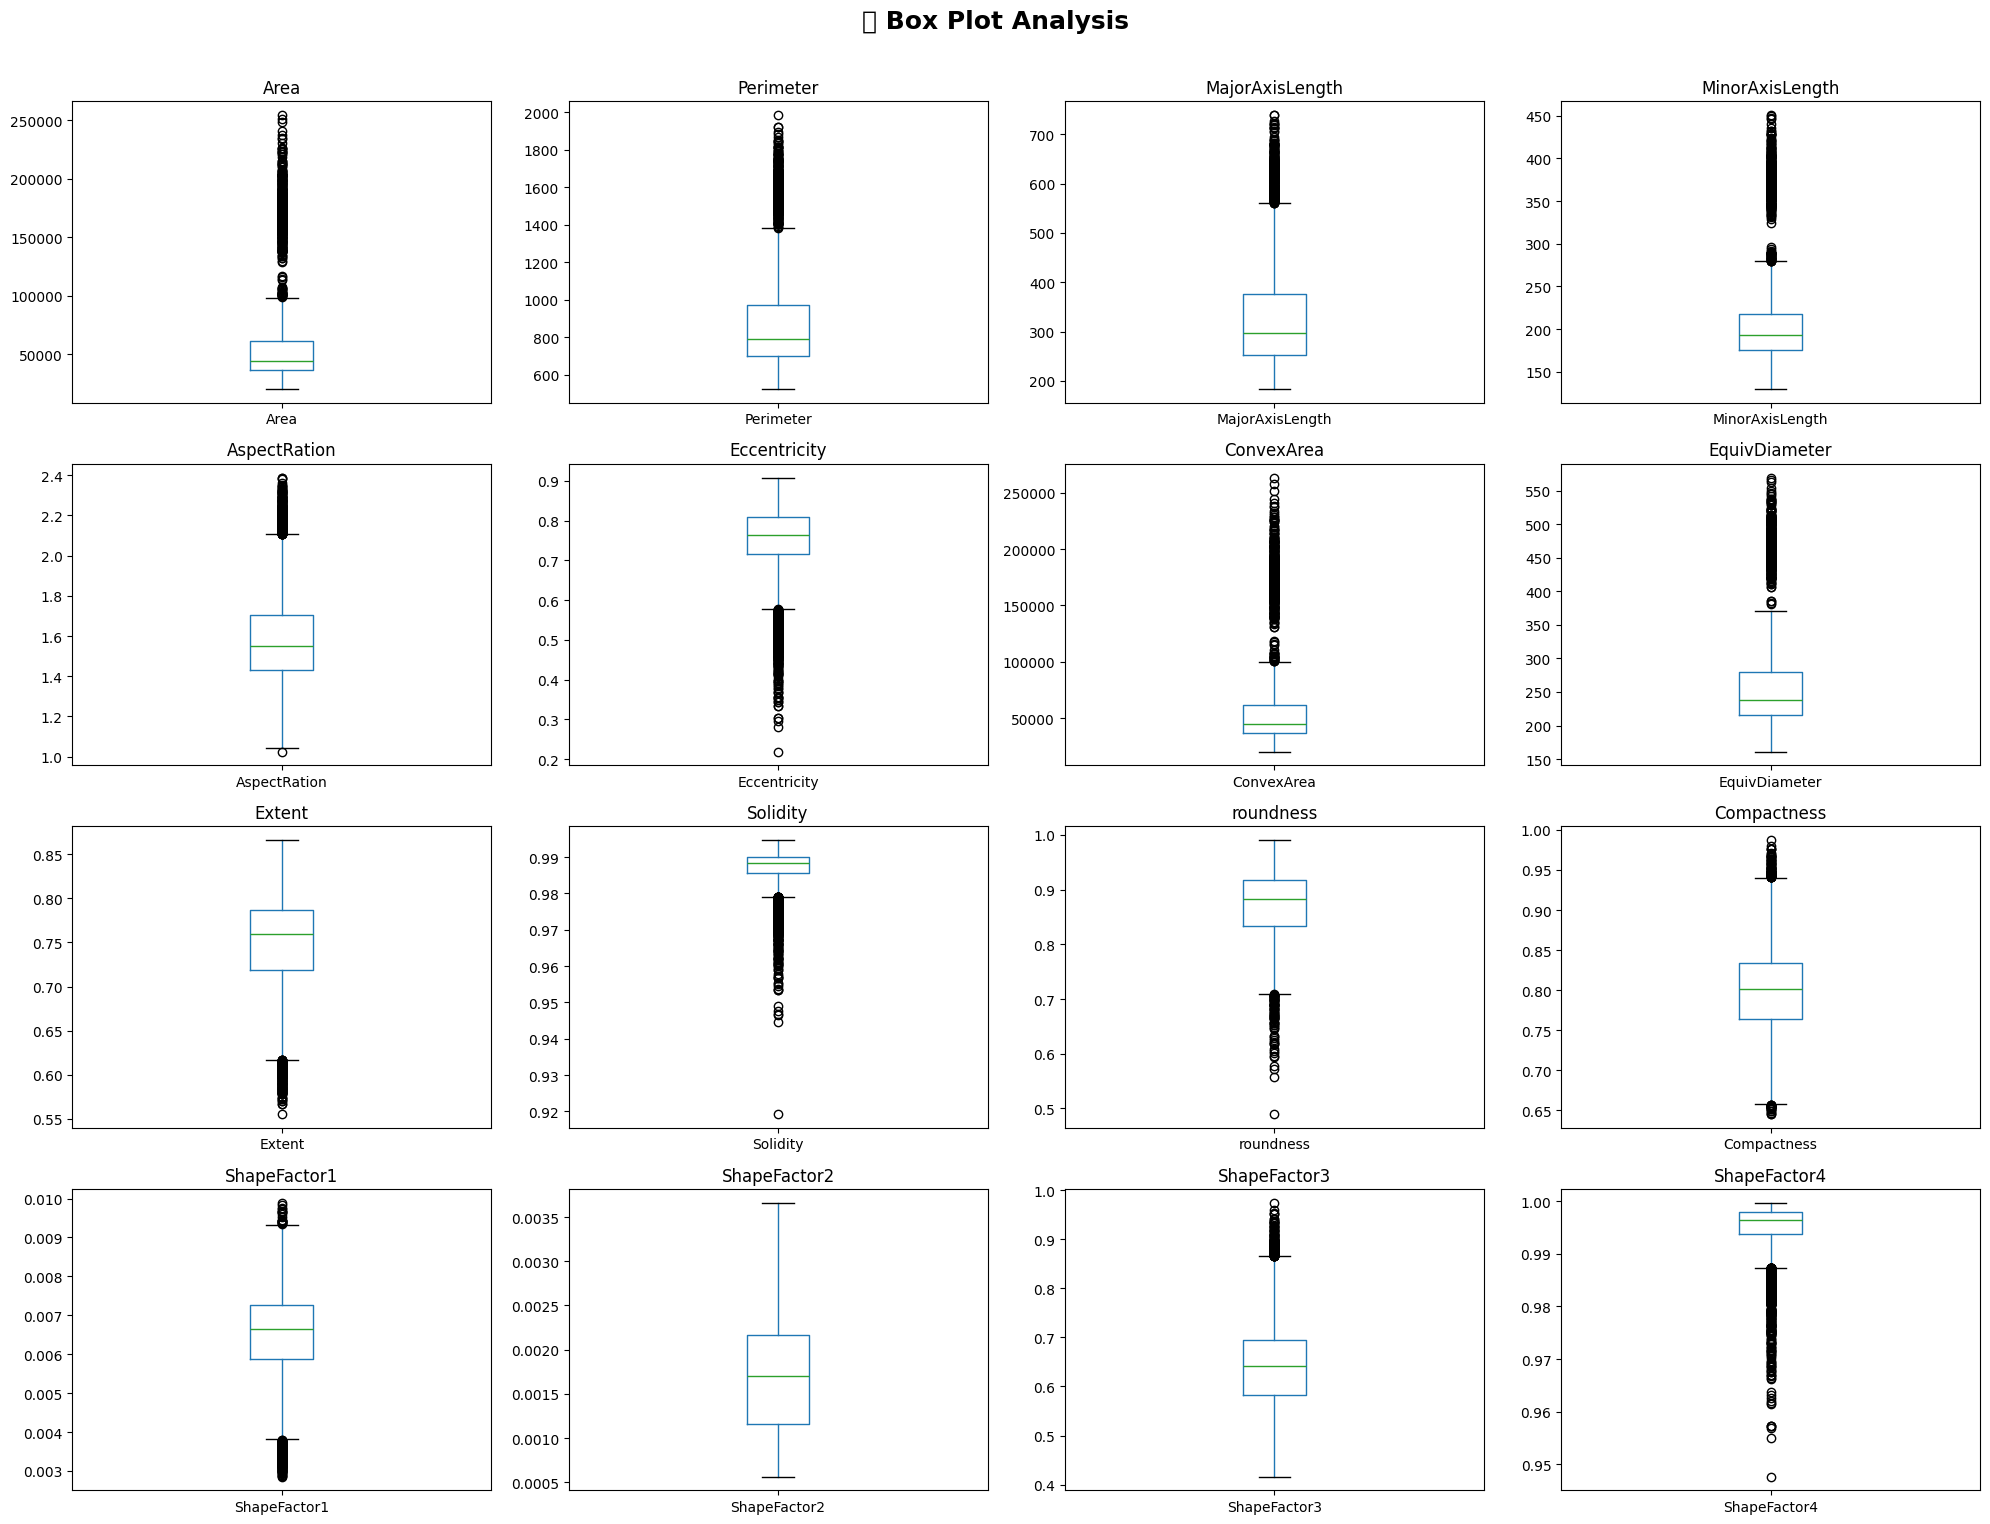

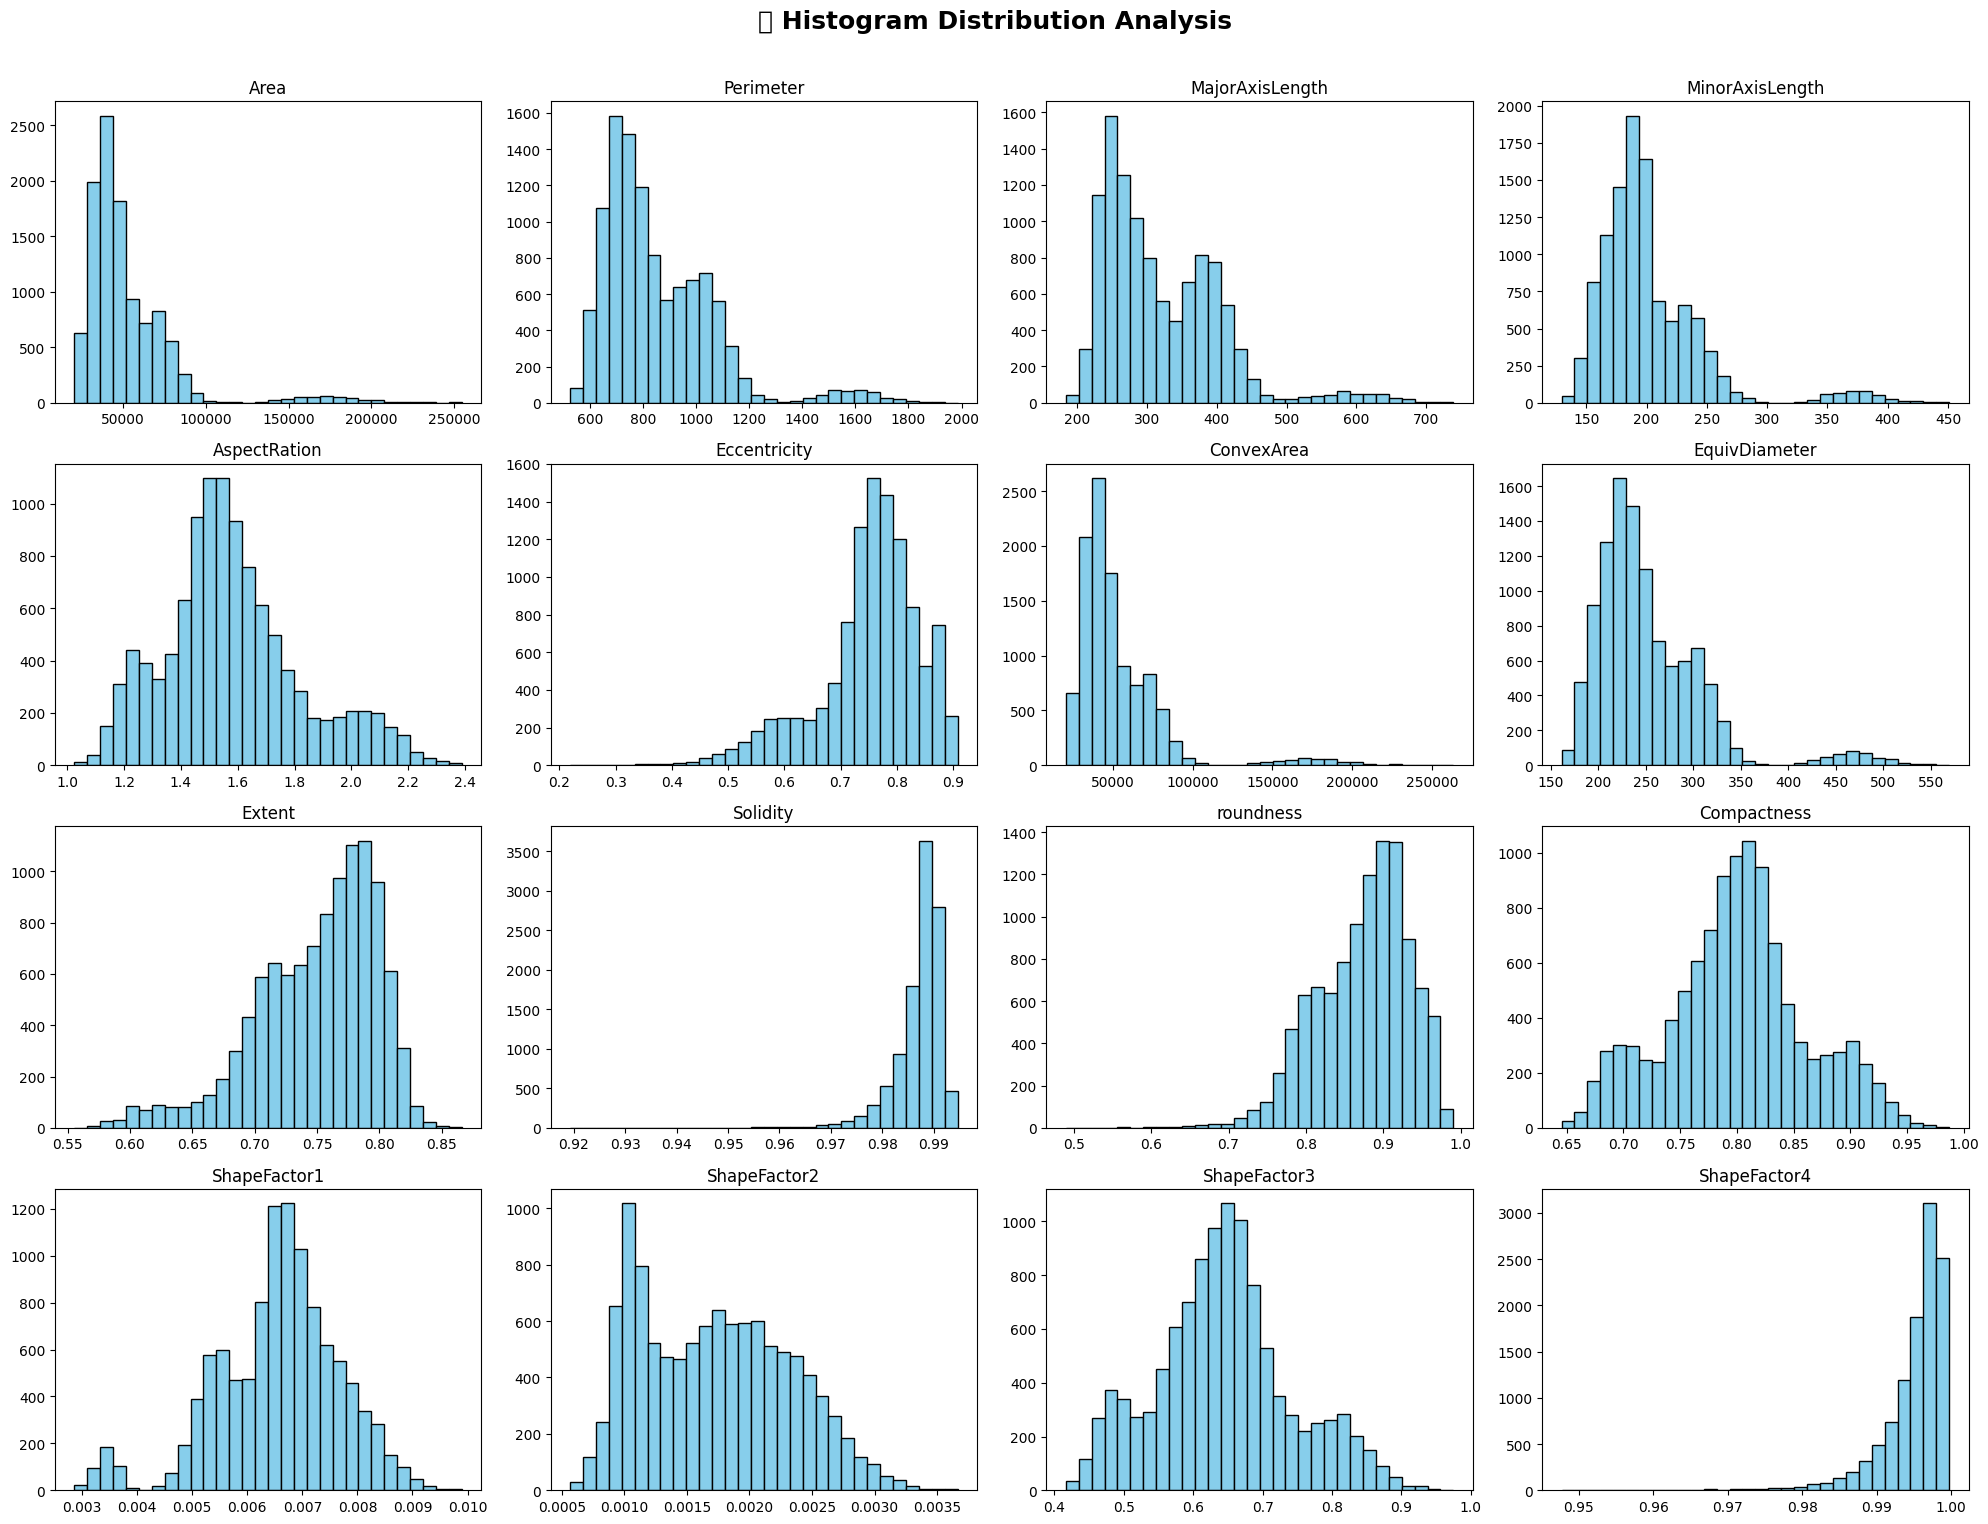

In [ ]:

def visualize_all_beans_features(df):
    # 1. Define features (clean and consistent)
    features = [f for f in df.select_dtypes(include=['number']).columns if f not in ['ID', 'y']]

    n_features = len(features)
    n_cols = 4
    n_rows = int(np.ceil(n_features / n_cols))

    # 2. Define a helper to setup and format the grid
    def setup_grid(title):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
        fig.suptitle(title, fontsize=18, fontweight='bold')
        return fig, axes.flatten()

    # ── PART 1: Box Plots ────────────────────────────────────────────────────
    fig1, axes1 = setup_grid('📦 Box Plot Analysis')
    for i, col in enumerate(features):
        df.boxplot(column=col, ax=axes1[i])
        axes1[i].set_title(col)
        axes1[i].grid(False)

    # 3. Clean up (Hide extra axes)
    for j in range(len(features), len(axes1)):
        axes1[j].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

    # ── PART 2: Histograms ───────────────────────────────────────────────────
    fig2, axes2 = setup_grid('📊 Histogram Distribution Analysis')
    for i, col in enumerate(features):
        axes2[i].hist(df[col], bins=30, color='skyblue', edgecolor='black')
        axes2[i].set_title(col)

    # Clean up
    for j in range(len(features), len(axes2)):
        axes2[j].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

# Run the function
visualize_all_beans_features(df_full)

## **3. Correlation Analysis (BEFORE SPLITTING)**

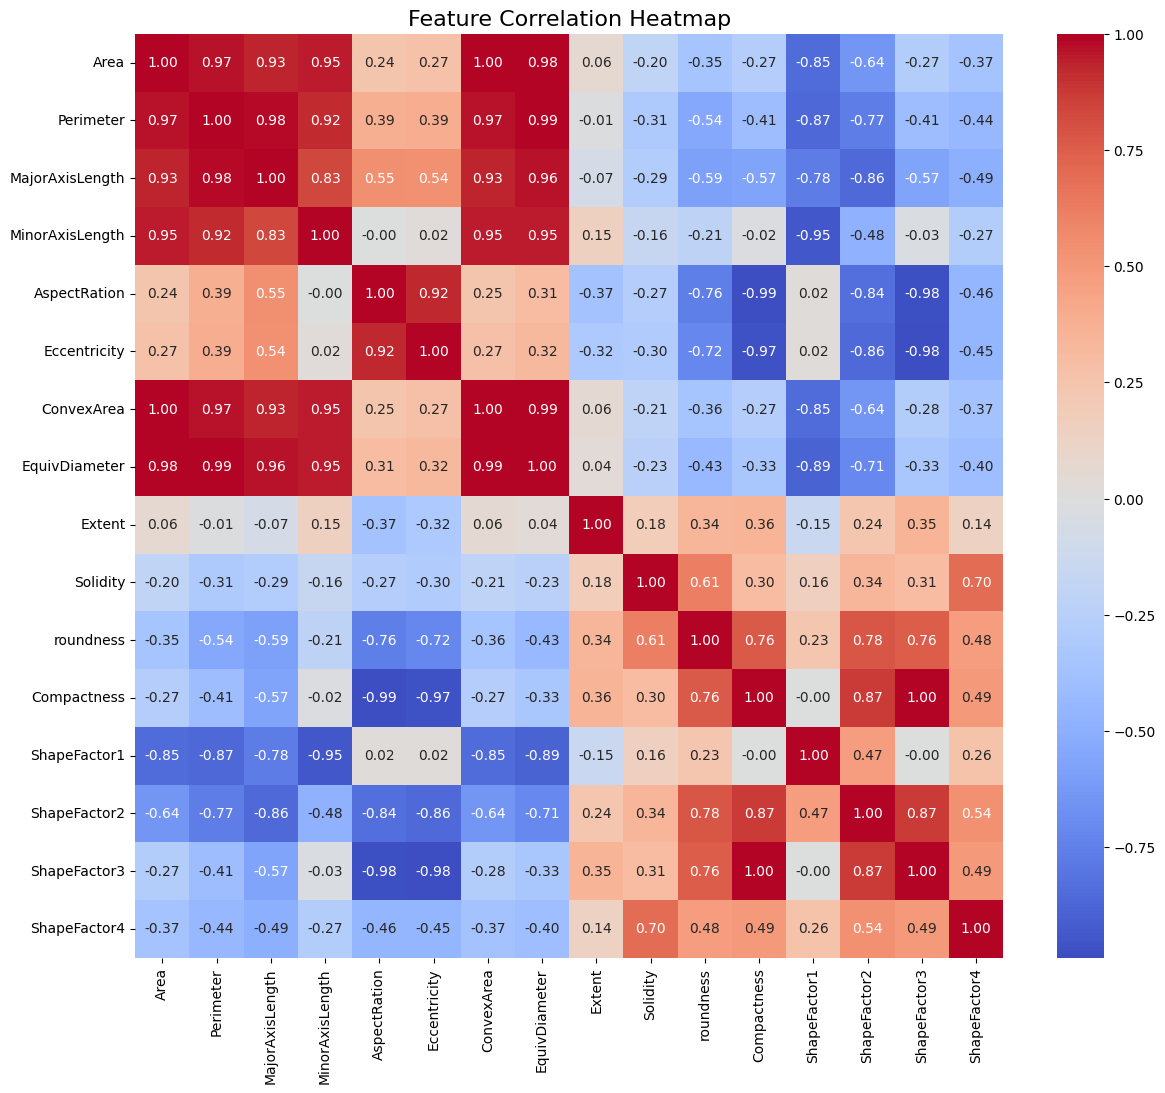

⚠️ High correlation found: Area & Perimeter |r| = 0.97
⚠️ High correlation found: Area & MajorAxisLength |r| = 0.93
⚠️ High correlation found: Area & MinorAxisLength |r| = 0.95
⚠️ High correlation found: Area & ConvexArea |r| = 1.00
⚠️ High correlation found: Area & EquivDiameter |r| = 0.98
⚠️ High correlation found: Area & ShapeFactor1 |r| = -0.85
⚠️ High correlation found: Perimeter & MajorAxisLength |r| = 0.98
⚠️ High correlation found: Perimeter & MinorAxisLength |r| = 0.92
⚠️ High correlation found: Perimeter & ConvexArea |r| = 0.97
⚠️ High correlation found: Perimeter & EquivDiameter |r| = 0.99
⚠️ High correlation found: Perimeter & ShapeFactor1 |r| = -0.87
⚠️ High correlation found: Perimeter & ShapeFactor2 |r| = -0.77
⚠️ High correlation found: MajorAxisLength & MinorAxisLength |r| = 0.83
⚠️ High correlation found: MajorAxisLength & ConvexArea |r| = 0.93
⚠️ High correlation found: MajorAxisLength & EquivDiameter |r| = 0.96
⚠️ High correlation found: MajorAxisLength & ShapeFacto

In [ ]:
def plot_correlation_heatmap(df):
    # TODO (a): Select only numeric columns, excluding 'ID' and 'y'.
    #           Compute the correlation matrix and display it as a heatmap.
    #           - Figure size: (14, 12)
    #           - Use the 'coolwarm' colormap, center=0, annotate with 2 decimal places
    #           - Return the correlation matrix
    # YOUR CODE HERE
    # 1. Select numeric columns, excluding ID and y
    numeric_df = df.select_dtypes(include=['number']).drop(['ID', 'y'], axis=1, errors='ignore')

    # 2. Compute the correlation matrix
    corr_matrix = numeric_df.corr()

    # 3. Display the heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix,
                annot=True,          # Annotate with numbers
                fmt=".2f",           # 2 decimal places
                cmap='coolwarm',     # Color scheme
                center=0)            # Center color at 0

    plt.title('Feature Correlation Heatmap', fontsize=16)
    plt.show()

    # 4. Return the matrix as requested
    return corr_matrix


def find_high_correlations(df, threshold=0.7):
    # 1. Get the numeric correlation matrix
    numeric_df = df.select_dtypes(include=['number']).drop(['ID', 'y'], axis=1, errors='ignore')
    corr_matrix = numeric_df.corr()

    found_pairs = False

    # 2. Iterate through the upper triangle of the matrix
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            # Get the correlation value
            r = corr_matrix.iloc[i, j]

            # Check the absolute threshold
            if abs(r) > threshold:
                print(f"⚠️ High correlation found: {cols[i]} & {cols[j]} |r| = {r:.2f}")
                found_pairs = True

    if not found_pairs:
        print(f"✅ No pairs with |r| > {threshold}")


corr_matrix = plot_correlation_heatmap(df_full)
find_high_correlations(df_full, threshold=0.7)

## **4. Train-Test Split (STRATIFIED)**

Stratified splitting prevents bias toward majority classes.

In [ ]:
def prepare_and_split_data(df, test_size=0.2, val_size=0.1, random_state=42):
    print("\n" + "="*70)
    print("✂️ DATA SPLITTING (STRATIFIED)")
    print("="*70)

    # TODO (a): Separate features (X) and target (y).
    #           Drop 'ID' and 'y' from X.  y is the 'y' column.
    # YOUR CODE HERE
    x=df.drop(['ID','y'],axis=1)
    y = df["y"]
    print(f'x datasets is :\n{x}')
    print(f'y datasets is :\n{y}')
    print(f"\n✅ Features: {x.shape}")
    print(f"✅ Target: {y.nunique()} classes")
    # TODO (b): Encode the target labels using LabelEncoder.
    #           Store the encoder as `label_encoder` and encoded labels as `y_encoded`.
    #           Print the mapping (index → class name).
    label_encoder = LabelEncoder()
    # YOUR CODE HERE :
    y_encoded = label_encoder.fit_transform(y)
    # YOUR CODE HERE (print mapping)
    # Print the mapping
    for index, value in enumerate(label_encoder.classes_):
      print(f"{index} → {value}")
    print("\n🏷️ Class Encoding:")

    # TODO (c): Split into (train+val) and test sets using train_test_split.
    #           Use stratify=y_encoded and the provided test_size / random_state.
    # YOUR CODE HERE
    X_temp, X_test, y_temp, y_test = train_test_split(
        x,
        y_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=y_encoded
        )
    # TODO (d): Split (train+val) into train and validation sets.
    #           Adjust val_size: val_size_adjusted = val_size / (1 - test_size)
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split (
        X_temp,
        y_temp,
        test_size= val_size_adjusted,
        random_state=random_state,
        stratify=y_temp
        )
    print(f"\n📦 Data Split:")
    print(f"   Training:   {X_train.shape[0]:5d} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
    print(f"   Validation: {X_val.shape[0]:5d} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
    print(f"   Test:       {X_test.shape[0]:5d} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

    return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

X_train, X_val, X_test, y_train, y_val, y_test, label_encoder = \
    prepare_and_split_data(df_full)


✂️ DATA SPLITTING (STRATIFIED)
x datasets is :
        Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0      58238    971.303       397.202654       186.945510      2.124697   
1      44515    757.601       265.590470       213.967453      1.241266   
2      31662    653.783       239.902428       168.421505      1.424417   
3      38778    734.020       268.446281       184.061923      1.458456   
4      42530    775.403       281.212824       193.236878      1.455275   
...      ...        ...              ...              ...           ...   
10829  37777    716.007       250.174662       192.704033      1.298233   
10830  32187    667.621       247.778775       165.786862      1.494562   
10831  81837   1095.937       433.838186       241.527026      1.796230   
10832  48212    826.362       309.639462       199.285811      1.553746   
10833  28026    610.943       215.446569       165.740377      1.299904   

       Eccentricity  ConvexArea  EquivDiameter    E

## **5. Handle Outliers (ONLY ON TRAIN)**

In [ ]:
def treat_beans_outliers(df, method='cap', lower_percentile=5, upper_percentile=95):
    df_treated = df.copy()

    if method != 'remove':
        columns = [col for col in df.columns if col != 'y']  # feature columns only

    if method == 'cap':
        print(f"\n🔒 Capping at {lower_percentile}th-{upper_percentile}th percentile")
        # TODO (a): For each feature column, compute the lower and upper cap values
        #           using the given percentiles.  Use .clip() to cap the values.
        #           Print columns where any values were actually capped.
        # YOUR CODE HERE
        for col in columns:
          lower_cap = df[col].quantile(lower_percentile / 100)
          upper_cap = df[col].quantile(upper_percentile / 100)
          outliers = (df[col] < lower_cap).any() or (df[col] > upper_cap).any()
          df_treated[col] = df_treated[col].clip(lower=lower_cap, upper=upper_cap)
          if outliers:
            print(f"Column '{col}' has been capped.")

# TODO (b): For each feature column, compute Q1, Q3, and IQR.
        #           Remove rows where any value falls outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
        #           Print the total number of rows removed.
        # YOUR CODE HERE
    elif method == 'remove':
        print(f"\n🗑️ Removing outliers (IQR method)")
        original_count = len(df_treated)
        columns = [col for col in df.columns if col != 'y']
        for col in columns:
            # computing the percentile for each quarter
            Q1 = df_treated[col].quantile(0.25)
            Q3 = df_treated[col].quantile(0.75)
            # computing the IQR
            IQR = Q3 - Q1
            # defining the lower and upper limits
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            df_treated = df_treated[(df_treated>=lower_limit) & (df_treated<=upper_limit)]
            rows_removed = original_count - len(df_treated)
            print(f"❌ Column '{col}' removed {rows_removed} rows.")

    return df_treated


# TODO (c): Apply outlier treatment ONLY to the training data.
#           Use method='cap'.  Keep X_val and X_test UNCHANGED.
#           Store results as X_train_treated and y_train_treated.
method = 'cap'
# YOUR CODE HERE
df_trained_combined = X_train.copy()
df_trained_combined['y'] = y_train
df_combined_train_treated = treat_beans_outliers(df_trained_combined, method='cap')
x_train_treated = df_combined_train_treated.drop('y', axis=1)
y_train_treated = df_combined_train_treated['y']
print(f'removed all the outliers from x & y trained data')
print(f'length of data for x and y trained after removing outliers is : {len(x_train_treated)} & {len(y_train_treated)}')


🔒 Capping at 5th-95th percentile
Column 'Area' has been capped.
Column 'Perimeter' has been capped.
Column 'MajorAxisLength' has been capped.
Column 'MinorAxisLength' has been capped.
Column 'AspectRation' has been capped.
Column 'Eccentricity' has been capped.
Column 'ConvexArea' has been capped.
Column 'EquivDiameter' has been capped.
Column 'Extent' has been capped.
Column 'Solidity' has been capped.
Column 'roundness' has been capped.
Column 'Compactness' has been capped.
Column 'ShapeFactor1' has been capped.
Column 'ShapeFactor2' has been capped.
Column 'ShapeFactor3' has been capped.
Column 'ShapeFactor4' has been capped.
removed all the outliers from x & y trained data
length of data for x and y trained after removing outliers is : 7583 & 7583


## **6. Handle Class Imbalance (ONLY ON TRAIN)**

In [ ]:
def check_and_handle_imbalance(X, y):
    # TODO (a): Use Counter(y) to get class counts.
    #           Compute imbalance_ratio = max_count / min_count.
    #           Print the distribution and the ratio.
    # YOUR CODE HERE

    # 1. Use Counter to get the count of each class
    counts = Counter(y)

    # 2. Get the max and min counts to calculate the ratio
    max_count = max(counts.values())
    min_count = min(counts.values())

    imbalance_ratio = max_count / min_count
    # YOUR CODE HERE (print distribution and ratio)
    # 3. Print the results
    print(f"\n⚖️ Class Distribution: {dict(counts)}")
    print(f"📊 Imbalance Ratio: {imbalance_ratio:.2f}")

    # TODO (b): Based on imbalance_ratio, decide the action:
    #           - ratio < 1.5  → "✅ Dataset is balanced"   → return X, y unchanged
    #           - 1.5 ≤ ratio < 3 → "⚠️ Mild imbalance - recommend class_weight='balanced'" → return X, y unchanged
    #           - ratio ≥ 3    → "🚨 Significant imbalance - applying SMOTE..."
    #             Apply SMOTE (random_state=42), print before/after counts, return resampled data.
    # YOUR CODE HERE
    # 1. Check the ratios and apply logic
    if imbalance_ratio < 1.5:
        print("✅ Dataset is balanced.")
        return X, y

    elif 1.5 <= imbalance_ratio < 3:
        print("⚠️ Mild imbalance - recommend class_weight='balanced'.")
        return X, y

    else:
        print("🚨 Significant imbalance - applying SMOTE...")
        # Get count before SMOTE
        before_counts = Counter(y)

        # Apply SMOTE
        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(X, y)

        # Get count after SMOTE
        after_counts = Counter(y_resampled)

        print(f"  📊 Before: {dict(before_counts)}")
        print(f"  📊 After:  {dict(after_counts)}")

        return X_resampled, y_resampled

# Handle imbalance ONLY on training data
X_train_balanced, y_train_balanced = check_and_handle_imbalance(x_train_treated, y_train_treated)

# Validation and test remain UNCHANGED
print("\n✅ Validation and test data: UNCHANGED")


⚖️ Class Distribution: {5: 1135, 2: 913, 6: 1476, 3: 1986, 0: 740, 4: 1041, 1: 292}
📊 Imbalance Ratio: 6.80
🚨 Significant imbalance - applying SMOTE...
  📊 Before: {5: 1135, 2: 913, 6: 1476, 3: 1986, 0: 740, 4: 1041, 1: 292}
  📊 After:  {5: 1986, 2: 1986, 6: 1986, 3: 1986, 0: 1986, 4: 1986, 1: 1986}

✅ Validation and test data: UNCHANGED


## **7. Feature Scaling (FIT ON TRAIN, TRANSFORM ALL)**

In [ ]:
def scale_data(X_train, X_val, X_test, method='standard', save_scaler=False, scaler_path="scaler.pkl"):
    # TODO (a): Choose the correct scaler object based on `method`:
    #           'standard' → StandardScaler   (prints "📊 Standard Scaling: (X - μ) / σ")
    #           'minmax'   → MinMaxScaler      (prints "📐 Min-Max Scaling: [0, 1]")
    #           'robust'   → RobustScaler      (prints "🎯 Robust Scaling: (X - median) / IQR")
    # YOUR CODE HERE
    if method == 'standard':
        scaler = StandardScaler()
        print("📊 Standard Scaling: (X - μ) / σ")
    elif method == 'minmax':
        scaler = MinMaxScaler()
        print("📐 Min-Max Scaling: [0, 1]")
    elif method == 'robust':
        scaler = RobustScaler()
        print("🎯 Robust Scaling: (X - median) / IQR")
    else:
      raise ValueError("UNKNOWN scaling method!")


    # TODO (b): Fit the scaler on X_train ONLY (never on val or test).
    #           Then transform all three splits.
    #           Return scaled DataFrames (preserve column names) and the fitted scaler.
    print("\n🔍 Fitting on TRAINING data only...")
    # YOUR CODE HERE
    scaler.fit(X_train)
    print("🔄 Transforming all datasets...")
    # YOUR CODE HERE
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
    # TODO (c): If save_scaler is True, save the fitted scaler using joblib
    #           to `scaler_path` and print a confirmation message.
    # YOUR CODE HERE
    if save_scaler:
        import joblib
        # Save the scaler object to the specified path
        joblib.dump(scaler, scaler_path)
        print(f"💾 Scaler successfully saved to: {scaler_path}")


    print(f"\n✅ Scaling complete!")
    print(f"   Train: {X_train_scaled.shape}")
    print(f"   Val:   {X_val_scaled.shape}")
    print(f"   Test:  {X_test_scaled.shape}")

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler


X_train_scaled, X_val_scaled, X_test_scaled, scaler = \
    scale_data(X_train_balanced, X_val, X_test, method='standard', save_scaler=True)

📊 Standard Scaling: (X - μ) / σ

🔍 Fitting on TRAINING data only...
🔄 Transforming all datasets...
💾 Scaler successfully saved to: scaler.pkl

✅ Scaling complete!
   Train: (13902, 16)
   Val:   (1084, 16)
   Test:  (2167, 16)


In [ ]:
import joblib
joblib.load('scaler.pkl')

StandardScaler()

## **8. Save Processed Data**

In [ ]:
# TODO (a): Save the three processed splits as CSV files to Google Drive.
#           Paths:
#             train → '.../machine_learning_project/train_processed.csv'
#             val   → '.../machine_learning_project/val_processed.csv'
#             test  → '.../machine_learning_project/test_processed.csv'
#           Each file should contain the scaled features + the 'y' label column.
#           Set index=False.

# 1. Setup the storage path
base_path = '/content/gdrive/MyDrive/machine_learning my copy/dry beans/'
os.makedirs(base_path, exist_ok=True)

print("🔗 Aligning and saving your processed data...")

# 2. Prepare the Training Set (Balanced + Scaled)
# We use .reset_index(drop=True) to make sure the features and labels line up perfectly
train_final = pd.concat([
    X_train_scaled.reset_index(drop=True),
    pd.Series(y_train_balanced, name='y').reset_index(drop=True)
], axis=1)

# 3. Prepare the Validation Set (Original + Scaled)
val_final = pd.concat([
    X_val_scaled.reset_index(drop=True),
    pd.Series(y_val, name='y').reset_index(drop=True)
], axis=1)

# 4. Prepare the Test Set (Original + Scaled)
test_final = pd.concat([
    X_test_scaled.reset_index(drop=True),
    pd.Series(y_test, name='y').reset_index(drop=True)
], axis=1)

# 5. Save the final CSVs to Google Drive
train_final.to_csv(os.path.join(base_path, 'train_processed.csv'), index=False)
val_final.to_csv(os.path.join(base_path, 'val_processed.csv'), index=False)
test_final.to_csv(os.path.join(base_path, 'test_processed.csv'), index=False)

print("\n🚀 All files saved successfully!")
print(f"📍 Files are in: {base_path}")
print(f"📊 Rows check -> Train: {len(train_final)} | Val: {len(val_final)} | Test: {len(test_final)}")

🔗 Aligning and saving your processed data...

🚀 All files saved successfully!
📍 Files are in: /content/gdrive/MyDrive/machine_learning my copy/dry beans/
📊 Rows check -> Train: 13902 | Val: 1084 | Test: 2167


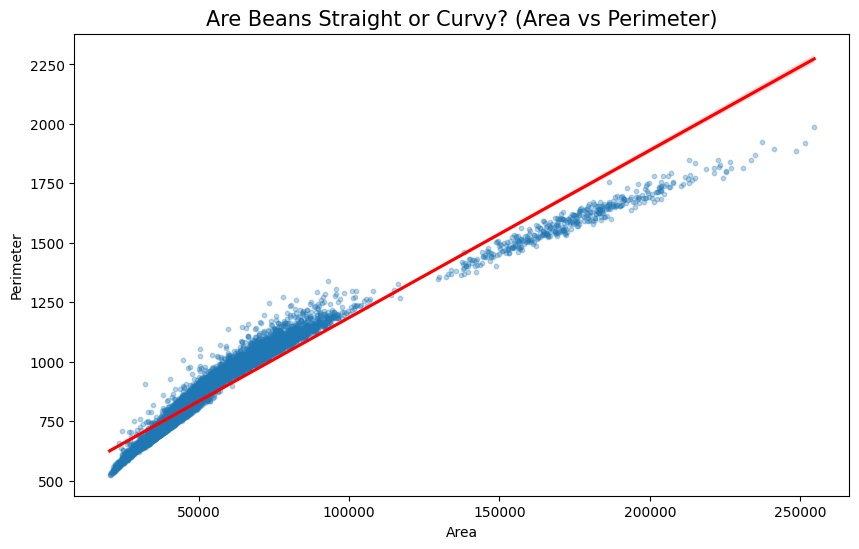

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Let's look at Area vs Perimeter - a classic "curvy" pair
plt.figure(figsize=(10, 6))

# scatter_kws makes the dots transparent so we can see the density
# line_kws makes the "Straight Line" stand out in red
sns.regplot(data=df_full, x='Area', y='Perimeter',
            scatter_kws={'alpha':0.3, 's':10},
            line_kws={'color':'red'})

plt.title('Are Beans Straight or Curvy? (Area vs Perimeter)', fontsize=15)
plt.show()

🚀 Training the Forest (this might take a few seconds)...

📊 MODEL PERFORMANCE REPORT:
Overall Accuracy: 92.53%
------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.94      0.94       106
      BOMBAY       0.98      1.00      0.99        42
        CALI       0.93      0.96      0.95       130
    DERMASON       0.91      0.92      0.92       284
       HOROZ       0.94      0.91      0.92       149
       SEKER       0.96      0.97      0.97       162
        SIRA       0.88      0.86      0.87       211

    accuracy                           0.93      1084
   macro avg       0.94      0.94      0.94      1084
weighted avg       0.93      0.93      0.93      1084



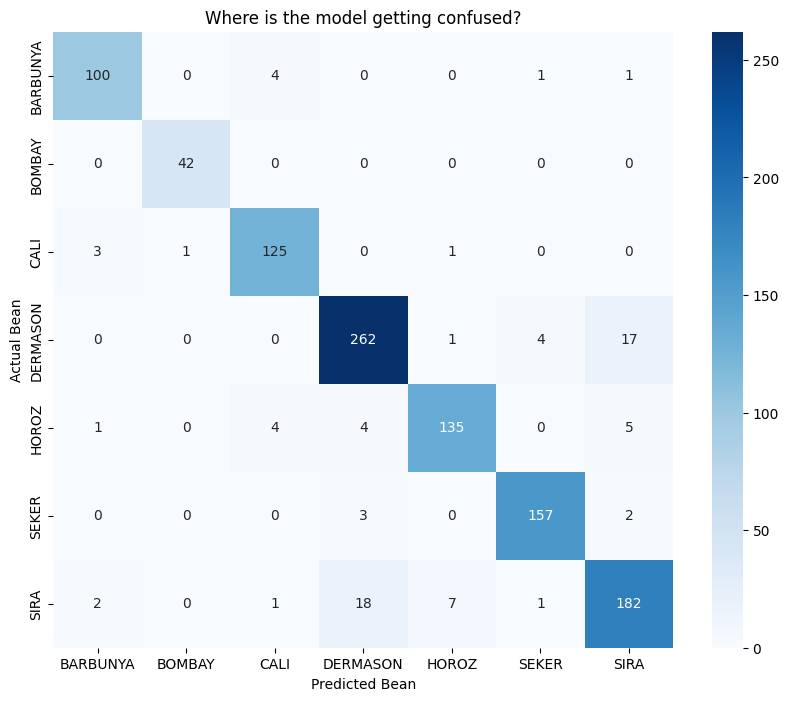

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# 1. Load the processed data from your Drive
base_path = '/content/gdrive/MyDrive/machine_learning my copy/dry beans/'
train_df = pd.read_csv(os.path.join(base_path, 'train_processed.csv'))
val_df = pd.read_csv(os.path.join(base_path, 'val_processed.csv'))

# 2. Separate Features (X) and Target (y)
X_train = train_df.drop('y', axis=1)
y_train = train_df['y']

X_val = val_df.drop('y', axis=1)
y_val = val_df['y']

# 3. Initialize the Random Forest
# n_estimators=100 means we are using a "committee" of 100 trees
# random_state=42 ensures you get the same result every time you run it
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("🚀 Training the Forest (this might take a few seconds)...")
rf_model.fit(X_train, y_train)

# 4. Make Predictions on the Validation set
y_pred = rf_model.predict(X_val)

# 5. Evaluate the Results
print("\n📊 MODEL PERFORMANCE REPORT:")
print(f"Overall Accuracy: {accuracy_score(y_val, y_pred):.2%}")
print("-" * 30)
# This shows Precision, Recall, and F1-Score for EVERY bean type
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

# 6. Visualize the Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Where is the model getting confused?')
plt.xlabel('Predicted Bean')
plt.ylabel('Actual Bean')
plt.show()

In [ ]:
# Initialize the Regularized Random Forest
# We are adding 'max_depth' and 'min_samples_leaf' to prevent overfitting
rf_regularized = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,         # Limits tree height; prevents 'memorizing' noise
    min_samples_leaf=5,   # Each 'leaf' must have 5+ beans; ignores tiny outliers
    max_features='sqrt',  # Forces trees to be diverse by looking at different features
    random_state=42,
    n_jobs=-1
)

# Training the model
print("🌲 Training the Regularized Forest...")
rf_regularized.fit(X_train, y_train)

# Predictions
y_pred_reg = rf_regularized.predict(X_val)
beans_names = list(label_encoder.classes_)

# Final Summary
print(f"\n✅ Regularized Accuracy: {accuracy_score(y_val, y_pred_reg):.2%}")
print("-" * 30)
print(classification_report(y_val, y_pred_reg,target_names=beans_names))

# NOTE FOR THE VIEWER:
# This version uses Structural Regularization (max_depth and min_samples_leaf).
# While the accuracy might be slightly lower than a 'perfect' 95%+,
# this model is actually BETTER FOR THE REAL WORLD because it is
# generalized and less likely to fail on new, unseen bean data.

🌲 Training the Regularized Forest...

✅ Regularized Accuracy: 92.34%
------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.94      0.94       106
      BOMBAY       0.98      1.00      0.99        42
        CALI       0.94      0.95      0.94       130
    DERMASON       0.92      0.90      0.91       284
       HOROZ       0.94      0.91      0.93       149
       SEKER       0.97      0.96      0.97       162
        SIRA       0.85      0.89      0.87       211

    accuracy                           0.92      1084
   macro avg       0.93      0.94      0.94      1084
weighted avg       0.92      0.92      0.92      1084



📊 FINAL HUMAN-READABLE REPORT:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.94      0.94       106
      BOMBAY       0.98      1.00      0.99        42
        CALI       0.94      0.95      0.94       130
    DERMASON       0.92      0.90      0.91       284
       HOROZ       0.94      0.91      0.93       149
       SEKER       0.97      0.96      0.97       162
        SIRA       0.85      0.89      0.87       211

    accuracy                           0.92      1084
   macro avg       0.93      0.94      0.94      1084
weighted avg       0.92      0.92      0.92      1084



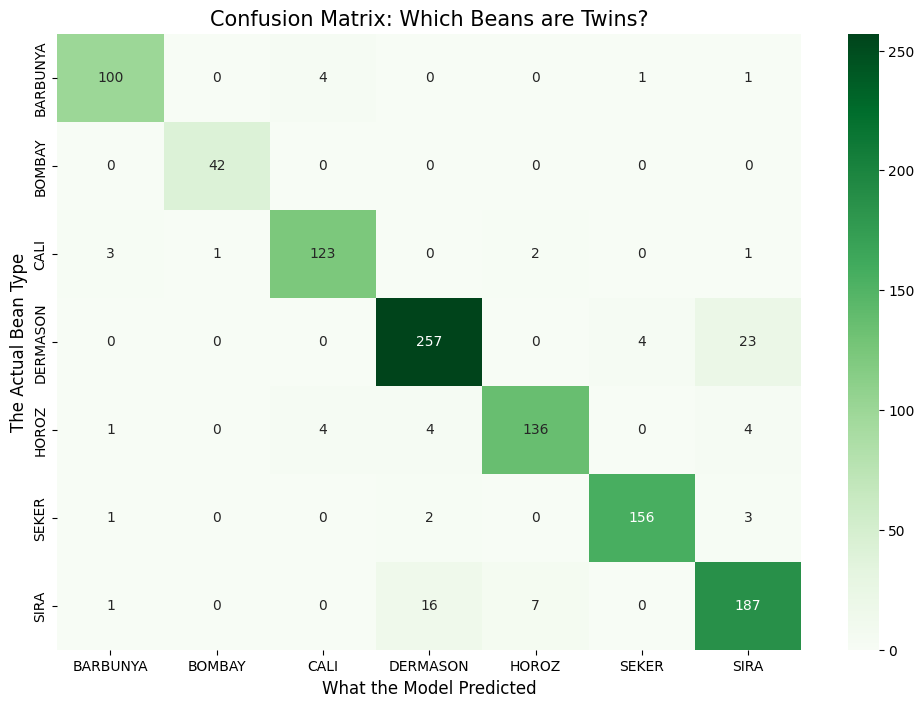

In [ ]:
# 1. Get the list of actual names from your encoder
bean_names = list(label_encoder.classes_)

# 2. Print the human-readable report
print("📊 FINAL HUMAN-READABLE REPORT:")
print(classification_report(y_val, y_pred_reg, target_names=bean_names))

# 3. Create the Confusion Matrix with Names
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_val, y_pred_reg)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=bean_names,
            yticklabels=bean_names)

plt.title('Confusion Matrix: Which Beans are Twins?', fontsize=15)
plt.xlabel('What the Model Predicted', fontsize=12)
plt.ylabel('The Actual Bean Type', fontsize=12)
plt.show()